Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

Load Data

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [3]:
print(nav.columns)
print(investor.columns)
print(holdings.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


1.Historical VaR (95%) and CVaR

In [31]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [32]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

2.Rolling 90-Day Sharpe Ratio

In [7]:
top5 = (
    performance
    .sort_values(
        "aum_crore",
        ascending=False
    )
    .head(5)
)["amfi_code"]

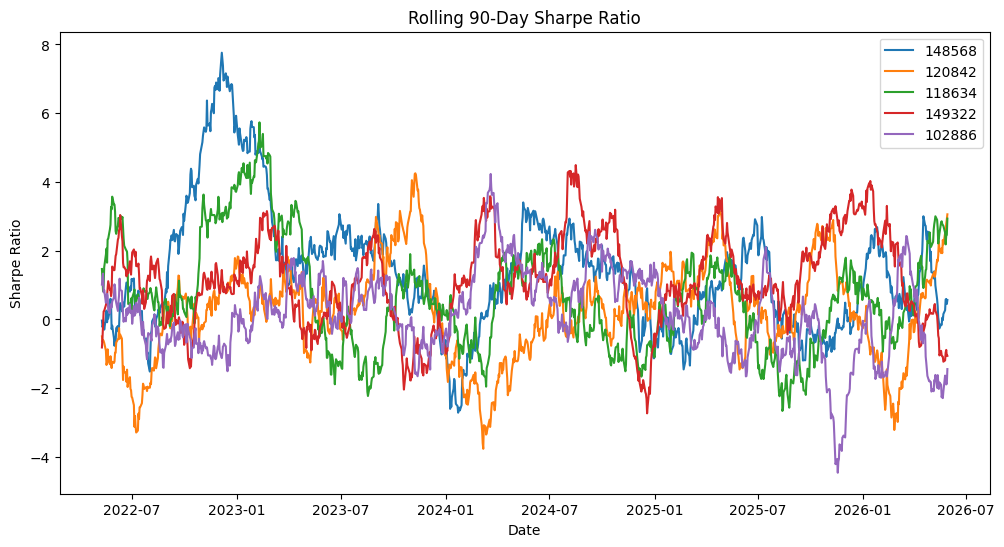

In [8]:
plt.figure(figsize=(12,6))

for fund in top5:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title(
    "Rolling 90-Day Sharpe Ratio"
)
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

3. Investor Cohort Analysis

In [9]:
investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [10]:
investor["cohort_year"] = (
    investor.groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

In [11]:
cohort_analysis = (
    investor
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
)

cohort_analysis

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


4. SIP Continuity Analysis

In [12]:
sip = investor[
    investor["transaction_type"] == "SIP"
].copy()

In [13]:
sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [14]:
continuity = (
    sip.groupby("investor_id")
       .agg(
           sip_count=(
               "transaction_date",
               "count"
           ),
           avg_gap=(
               "gap_days",
               "mean"
           )
       )
)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


5. Sector HHI Concentration

In [15]:
hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x:
        np.sum(
            (x/100)**2
        )
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [19]:
print(performance["risk_grade"].unique())

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


In [21]:
print(performance["risk_grade"].isna().sum())

print(performance[["risk_grade","scheme_name"]].head(10))

0
  risk_grade                                        scheme_name
0   Moderate          SBI Bluechip Fund - Regular Plan - Growth
1   Moderate           SBI Bluechip Fund - Direct Plan - Growth
2  Very High         SBI Small Cap Fund - Regular Plan - Growth
3  Very High          SBI Small Cap Fund - Direct Plan - Growth
4        Low       SBI Magnum Gilt Fund - Regular Plan - Growth
5   Moderate          HDFC Top 100 Fund - Regular Plan - Growth
6   Moderate           HDFC Top 100 Fund - Direct Plan - Growth
7       High  HDFC Mid-Cap Opportunities Fund - Regular - Gr...
8       High  HDFC Mid-Cap Opportunities Fund - Direct - Growth
9        Low       HDFC Short Term Debt Fund - Regular - Growth


In [22]:
print(performance["risk_grade"].value_counts(dropna=False))

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [23]:
performance[
    performance["risk_grade"] == "Low"
][["scheme_name","risk_grade","sharpe_ratio"]].head()

,scheme_name,risk_grade,sharpe_ratio
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52
9,HDFC Short Term Debt Fund - Regular - Growth,Low,1.84
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
19,Nippon India Gilt Securities Fund - Regular - ...,Low,1.33
23,Kotak Liquid Fund - Regular - Growth,Low,6.18


In [24]:
risk = "Low"

recommendations = (
    performance[
        performance["risk_grade"] == risk
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

recommendations[
    [
        "scheme_name",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct"
    ]
]

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14


6. Create recommender.py/

In [26]:
import pandas as pd

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

risk = "Low"      # Change to Low / Moderate / High

recommendations = (
    performance[
        performance["risk_grade"] == risk
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

print("\nTop Recommended Funds:\n")

print(
    recommendations[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]
)


Top Recommended Funds:

                                 scheme_name risk_grade  sharpe_ratio  \
14  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68   
23      Kotak Liquid Fund - Regular - Growth        Low          6.18   
30       ABSL Liquid Fund - Regular - Growth        Low          5.14   

    return_3yr_pct  
14            7.68  
23            6.18  
30            5.14  


In [27]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [28]:
cohort_analysis.head()

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [29]:
continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [30]:
hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


# Advanced Insights

### 1. Downside Risk Analysis

Fund 101207 exhibited the highest downside risk among the analyzed schemes, with a VaR (95%) of -2.60% and a CVaR of -3.25%. This indicates that during adverse market conditions, the fund is expected to experience larger losses compared to its peers.

### 2. Investor Cohort Trends

The 2024 investor cohort contributed the largest investment volume, with total investments exceeding ₹3.49 billion and an average SIP amount of ₹107,423. This suggests strong participation from recently onboarded investors.

### 3. SIP Continuity Assessment

Multiple investors were identified as "At Risk" due to irregular SIP contributions. For example, investor INV000004 had an average gap of 85.4 days between SIP transactions, significantly higher than the recommended monthly frequency.

### 4. Portfolio Concentration Risk

Fund 101207 recorded the highest Herfindahl-Hirschman Index (HHI) value of 0.2007, indicating a relatively concentrated portfolio. Higher concentration may increase exposure to sector-specific or stock-specific risks.

### 5. Risk-Based Fund Recommendations

Based on Sharpe Ratio rankings within the Low-Risk category, the top-performing funds were:

* ICICI Prudential Liquid Fund (Sharpe Ratio: 7.68)
* Kotak Liquid Fund (Sharpe Ratio: 6.18)
* ABSL Liquid Fund (Sharpe Ratio: 5.14)

These funds delivered the strongest risk-adjusted returns among low-risk investment options.
